#Sistemas de recomendación
###Movie lenses

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Machine Learning - Python/Datasets - Machine Learning/ml-100k/u.data.csv', sep = '\t', header = None)

In [4]:
df.head(10)

,0,1,2,3
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596
5,298,474,4,884182806
6,115,265,2,881171488
7,253,465,5,891628467
8,305,451,3,886324817
9,6,86,3,883603013


In [5]:
df.columns = ['UserID', 'ItemID', 'Rating', 'TimeStamp']

In [6]:
df.head(10)

,UserID,ItemID,Rating,TimeStamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596
5,298,474,4,884182806
6,115,265,2,881171488
7,253,465,5,891628467
8,305,451,3,886324817
9,6,86,3,883603013


##Análisis exploratorio de los datos

In [7]:
import matplotlib.pyplot as plt

(array([ 6110.,     0., 11370.,     0.,     0., 27145.,     0., 34174.,
            0., 21201.]),
 array([1. , 1.4, 1.8, 2.2, 2.6, 3. , 3.4, 3.8, 4.2, 4.6, 5. ]),
 <BarContainer object of 10 artists>)

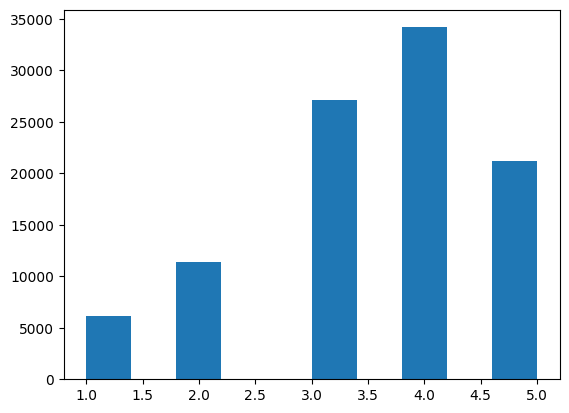

In [8]:
plt.hist(df['Rating'])

(array([11459.,  5724., 19359.,  9315.,  9396., 10083.,  6175.,  9603.,
        10048.,  8838.]),
 array([8.74724710e+08, 8.76580903e+08, 8.78437096e+08, 8.80293288e+08,
        8.82149481e+08, 8.84005674e+08, 8.85861867e+08, 8.87718060e+08,
        8.89574252e+08, 8.91430445e+08, 8.93286638e+08]),
 <BarContainer object of 10 artists>)

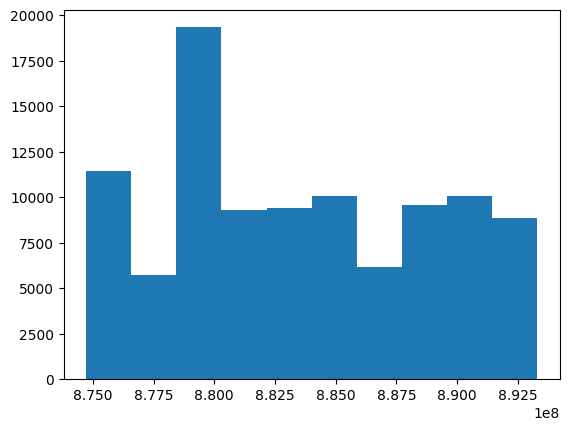

In [9]:
plt.hist(df['TimeStamp'])

In [10]:
'''
Interpretación: 6110 personas han calificado películas con una estrella,
11370 personas han calificado películas con dos estrellas,
11370 personas han calificado películas con dos estrellas,
27145 personas han calificado películas con tres estrellas,
34174 personas han calificado películas con 4 estrellas,
21201 personas han calificado películas con 5 estrellas.
'''
df.groupby(['Rating'])['UserID'].count()

,UserID
Rating,
1,6110
2,11370
3,27145
4,34174
5,21201


In [11]:
#Interpretación: 452 personas han visto la película 1, 131 la película 2...
df.groupby(['ItemID'])['UserID'].count()

,UserID
ItemID,
1,452
2,131
3,90
4,209
5,86
...,...
1678,1
1679,1
1680,1


(array([1.146e+03, 2.490e+02, 1.390e+02, 6.700e+01, 3.800e+01, 2.400e+01,
        7.000e+00, 5.000e+00, 6.000e+00, 1.000e+00]),
 array([  1. ,  59.2, 117.4, 175.6, 233.8, 292. , 350.2, 408.4, 466.6,
        524.8, 583. ]),
 <BarContainer object of 10 artists>)

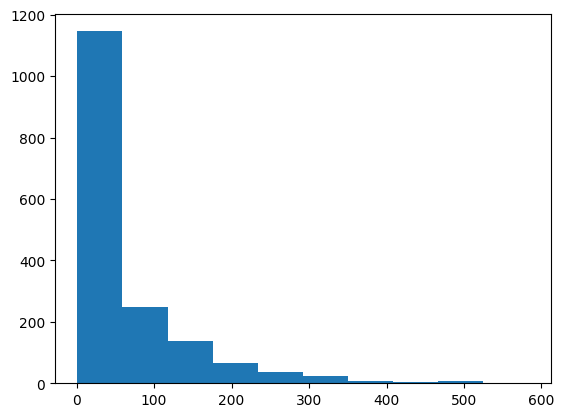

In [12]:
plt.hist(df.groupby(['ItemID'])['UserID'].count())

### Representación en forma matricial

In [13]:
import numpy as np

In [14]:
n_users = df['UserID'].nunique()
n_users

943

In [15]:
n_items = df['ItemID'].nunique()
n_items

1682

In [16]:
ratings = np.zeros((n_users, n_items))

In [17]:
ratings

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [18]:
ratings.shape

(943, 1682)

In [19]:
df.head(10)

,UserID,ItemID,Rating,TimeStamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596
5,298,474,4,884182806
6,115,265,2,881171488
7,253,465,5,891628467
8,305,451,3,886324817
9,6,86,3,883603013


In [20]:
for row in df.itertuples():
  ratings[row[1] - 1, row[2] - 1] = row[3]

In [21]:
ratings

array([[5., 3., 4., ..., 0., 0., 0.],
       [4., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [5., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 5., 0., ..., 0., 0., 0.]])

In [22]:
ratings.nonzero()[0]

array([  0,   0,   0, ..., 942, 942, 942])

In [23]:
sparsity = float(len(ratings.nonzero()[0]))
sparsity

100000.0

In [24]:
sparsity = sparsity / (ratings.shape[0] * ratings.shape[1]) * 100
sparsity

6.304669364224531

In [25]:
print('El coeficiente de esparseidad es de: ' + str(sparsity) + '%')

El coeficiente de esparseidad es de: 6.304669364224531%


###Crear conjuntos de entrenamiento y validación

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
ratings_train, ratings_test = train_test_split(ratings, test_size = 0.30, random_state = 42)

In [28]:
ratings_train.shape

(660, 1682)

###Filtro colaborativo basado en usuarios
* Matriz de similaridad (distancia del coseno).
* Predecir la valoración desconocida de un ítem 'i' para un usuario activo 'u' basándonos en la suma ponderada de todas las valoraciones del resto de usuarios para dicho ítem.
*Recomendaremos los nuevos ítems a los usuarios según lo establecido en los pasos anteriores.

In [29]:
import numpy as np
import sklearn

In [30]:
sim_matrix = 1 - sklearn.metrics.pairwise.cosine_distances(ratings_train)

In [31]:
sim_matrix.shape

(660, 660)

In [32]:
sim_matrix

array([[1.        , 0.17448349, 0.18009754, ..., 0.13331459, 0.17695593,
        0.21882481],
       [0.17448349, 1.        , 0.07993097, ..., 0.07175808, 0.09552622,
        0.05512655],
       [0.18009754, 0.07993097, 1.        , ..., 0.0191736 , 0.02233385,
        0.10310785],
       ...,
       [0.13331459, 0.07175808, 0.0191736 , ..., 1.        , 0.04853428,
        0.05142508],
       [0.17695593, 0.09552622, 0.02233385, ..., 0.04853428, 1.        ,
        0.1198022 ],
       [0.21882481, 0.05512655, 0.10310785, ..., 0.05142508, 0.1198022 ,
        1.        ]])

In [33]:
users_predictions = sim_matrix.dot(ratings_train) / np.array([np.abs(sim_matrix).sum(axis = 1)]).T

In [34]:
users_predictions

array([[2.10259747e+00, 5.86975978e-01, 3.40264192e-01, ...,
        0.00000000e+00, 7.33611460e-03, 6.04379414e-03],
       [1.40999723e+00, 2.91863934e-01, 2.68085289e-01, ...,
        0.00000000e+00, 3.50378592e-03, 2.32963985e-03],
       [1.69014833e+00, 3.13648440e-01, 3.26127887e-01, ...,
        0.00000000e+00, 3.25391767e-03, 1.77210119e-03],
       ...,
       [1.73393747e+00, 4.06719333e-01, 3.21166908e-01, ...,
        0.00000000e+00, 2.71269625e-03, 9.00511411e-03],
       [2.34361031e+00, 8.10544770e-01, 4.73941025e-01, ...,
        0.00000000e+00, 1.01130066e-02, 9.66427605e-03],
       [2.36796969e+00, 5.98146138e-01, 3.85569804e-01, ...,
        0.00000000e+00, 6.39996638e-03, 5.37442746e-03]])

In [35]:
from sklearn.metrics import mean_squared_error

In [36]:
def get_mse(preds, actuals):
    preds = preds[actuals.nonzero()].flatten()
    actuals = actuals[actuals.nonzero()].flatten()
    return mean_squared_error(preds, actuals)

In [37]:
get_mse(users_predictions, ratings_train)

7.878218313143215

In [38]:
get_mse(users_predictions, ratings_test)

8.745164067978985

#Filtro colaborativo basado en KNN.

In [39]:
from sklearn.neighbors import NearestNeighbors

In [40]:
k = 10

In [41]:
neighbors = NearestNeighbors(n_neighbors = k, metric = 'cosine')

In [42]:
neighbors.fit(ratings_train)

NearestNeighbors(metric='cosine', n_neighbors=10)

In [43]:
top_k_distances, top_k_users = neighbors.kneighbors(ratings_train, return_distance = True)

In [44]:
top_k_distances.shape

(660, 10)

In [45]:
top_k_users.shape

(660, 10)

In [46]:
top_k_distances[0]

array([0.        , 0.49780748, 0.55784838, 0.56965585, 0.57163621,
       0.57520588, 0.58205174, 0.59226081, 0.59498626, 0.60010163])

In [47]:
top_k_users[0]

array([  0, 211,  16, 185, 101, 155, 169, 407, 112, 618])

In [48]:
users_predicts_k = np.zeros(ratings_train.shape)

In [49]:
for i in range(ratings_train.shape[0]): # Para cada usuario del conjunto de entrenamiento
    users_predicts_k[i, :] = top_k_distances[i].dot(ratings_train[top_k_users[i]]) / np.array([np.abs(top_k_distances[i]).sum(axis = 0)]).T

In [50]:
users_predicts_k.shape

(660, 1682)

In [51]:
users_predicts_k

array([[2.51922614, 1.25840774, 0.35014799, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [1.05960476, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [3.54783988, 2.09071639, 2.12255948, ..., 0.        , 0.        ,
        0.        ],
       [2.68028305, 0.46761522, 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [52]:
get_mse(users_predicts_k, ratings_train)

4.233636216181872

In [53]:
get_mse(users_predicts_k, ratings_test)

8.618022216597852

###Filtro colaborativo basado en ítems:

In [54]:
n_movies = ratings.shape[1]
n_movies

1682

In [55]:
neighbors = NearestNeighbors(n_neighbors = n_movies, metric = 'cosine')

In [56]:
neighbors.fit(ratings_train.T)

NearestNeighbors(metric='cosine', n_neighbors=1682)

In [57]:
top_k_distances, top_k_items = neighbors.kneighbors(ratings_train.T, return_distance = True)

In [58]:
top_k_distances.shape

(1682, 1682)

In [59]:
top_k_items.shape

(1682, 1682)

In [60]:
top_k_users

array([[  0, 211,  16, ..., 407, 112, 618],
       [  1, 123, 484, ..., 278, 292, 608],
       [  2, 428,  39, ..., 186, 583, 564],
       ...,
       [657, 287, 271, ..., 651, 168, 516],
       [658, 407, 184, ..., 198, 589, 151],
       [659, 524, 230, ..., 571, 216,  70]])

In [61]:
item_preds = ratings_train.dot(top_k_distances) / np.array([np.abs(top_k_distances).sum(axis = 1)])

In [62]:
item_preds.shape

(660, 1682)

In [63]:
item_preds

array([[5.26828520e-17, 1.81491881e-01, 1.84975068e-01, ...,
        3.53151011e-01, 3.61714398e-01, 3.61072723e-01],
       [1.51443061e-17, 2.76845163e-02, 2.75479698e-02, ...,
        4.81569560e-02, 4.93246906e-02, 4.92371895e-02],
       [1.11971199e-17, 2.56853867e-02, 2.68507499e-02, ...,
        4.45897741e-02, 4.56710098e-02, 4.55899903e-02],
       ...,
       [1.03915717e-17, 6.34395655e-02, 6.23832360e-02, ...,
        1.02259215e-01, 1.04738849e-01, 1.04553044e-01],
       [4.14857320e-17, 1.67722238e-01, 1.68514946e-01, ...,
        3.23424495e-01, 3.31267058e-01, 3.30679396e-01],
       [1.91720470e-17, 2.52640159e-02, 2.61251908e-02, ...,
        6.24256837e-02, 6.39394137e-02, 6.38259864e-02]])

In [64]:
get_mse(item_preds, ratings_train)

11.460962134170675

In [65]:
get_mse(item_preds, ratings_test)

12.127257997874693

###Filtrado colaborativo basado en KNN

In [66]:
k = 30
neighbors = NearestNeighbors(n_neighbors = k, metric = 'cosine')
neighbors.fit(ratings_train)
top_k_distances, top_k_items = neighbors.kneighbors(ratings_train, return_distance = True)

In [67]:
top_k_items.shape

(660, 30)

In [68]:
top_k_distances[0]

array([0.        , 0.49780748, 0.55784838, 0.56965585, 0.57163621,
       0.57520588, 0.58205174, 0.59226081, 0.59498626, 0.60010163,
       0.6026071 , 0.60709272, 0.60743669, 0.6076299 , 0.61655301,
       0.6168716 , 0.61912502, 0.62253772, 0.62412271, 0.62484485,
       0.62593731, 0.63291641, 0.63461068, 0.63486702, 0.63580321,
       0.63608879, 0.63642614, 0.63648522, 0.63672451, 0.6370721 ])

In [69]:
preds = np.zeros(ratings_train.shape)

for i in range(ratings_train.shape[0]):
    preds[i, :] = top_k_distances[i].dot(ratings_train[top_k_items[i]]) / np.array([np.abs(top_k_distances[i]).sum(axis = 0)]).T

In [70]:
preds.shape

(660, 1682)

In [71]:
ratings_train.shape

(660, 1682)

In [72]:
ratings_test.shape

(283, 1682)

In [73]:
get_mse(preds, ratings_train)

4.571702030597622

In [74]:
get_mse(preds, ratings_test)

8.320510116081818

### Filtrado colaborativo basado en KNN

In [75]:
k = 30
neighbors = NearestNeighbors(n_neighbors = k, metric = 'cosine')
neighbors.fit(ratings_train.T)
top_k_distances, top_k_items = neighbors.kneighbors(ratings_train.T, return_distance = True)

In [76]:
top_k_distances.shape

(1682, 30)

In [77]:
top_k_items[0]

array([  0,  49, 180, 120, 116, 404,   6, 221,  99, 173, 150, 236,  27,
       171, 117, 256, 203,  78, 741,  94,  97,  68, 209, 124,  81,  24,
       167, 172, 227,  14])

In [78]:
top_k_distances[0]

array([0.        , 0.27629809, 0.30113328, 0.30472713, 0.3403217 ,
       0.34726332, 0.35536283, 0.35721264, 0.36136105, 0.36866657,
       0.37329885, 0.38428119, 0.39574721, 0.39737686, 0.40014911,
       0.40072802, 0.40161383, 0.40352935, 0.40451002, 0.41645588,
       0.42143241, 0.42475747, 0.42654625, 0.42764277, 0.42852725,
       0.43039718, 0.430995  , 0.43390098, 0.4349473 , 0.4355882 ])

In [79]:
preds = np.zeros(ratings_train.T.shape)

for i in range(ratings_train.T.shape[0]):
    preds[i, :] = top_k_distances[i].dot(ratings_train.T[top_k_items[i]]) / np.array([np.abs(top_k_distances[i]).sum(axis = 0)]).T

In [80]:
get_mse(preds, ratings_train.T)

3.741306021148668

In [81]:
get_mse(preds, ratings_test.T)

8.639650337967288